In [17]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
import os

In [18]:
model_configs = {
    'customcnn': 'outputs/customcnn/logs/history.json',
    'resnet18_finetune': 'outputs/resnet18_finetune/logs/history.json',
    'resnet18_frozen': 'outputs/resnet18_frozen/logs/history.json',
    'resnet18_scratch': 'outputs/resnet18_scratch/logs/history.json',
    'vit_finetune': 'outputs/vit_finetune/logs/history.json',
    'vit_frozen': 'outputs/vit_frozen/logs/history.json',
    'vit_scratch': 'outputs/vit_scratch/logs/history.json',
}

histories = {}

for model_name, path in model_configs.items():
    try:
        with open(path, 'r') as f:
            histories[model_name] = json.load(f)
        print(f"Loaded {model_name}")
    except FileNotFoundError:
        print(f"Warning: History file not found for {model_name} at {path}")

Loaded customcnn
Loaded resnet18_finetune
Loaded resnet18_frozen
Loaded resnet18_scratch
Loaded vit_finetune
Loaded vit_frozen
Loaded vit_scratch


Minimum epochs across all models: 10
Saved: outputs/customcnn/figures/customcnn_training_analysis.png
Saved: outputs/resnet18_finetune/figures/resnet18_finetune_training_analysis.png
Saved: outputs/resnet18_frozen/figures/resnet18_frozen_training_analysis.png
Saved: outputs/resnet18_scratch/figures/resnet18_scratch_training_analysis.png
Saved: outputs/vit_finetune/figures/vit_finetune_training_analysis.png
Saved: outputs/vit_frozen/figures/vit_frozen_training_analysis.png
Saved: outputs/vit_scratch/figures/vit_scratch_training_analysis.png


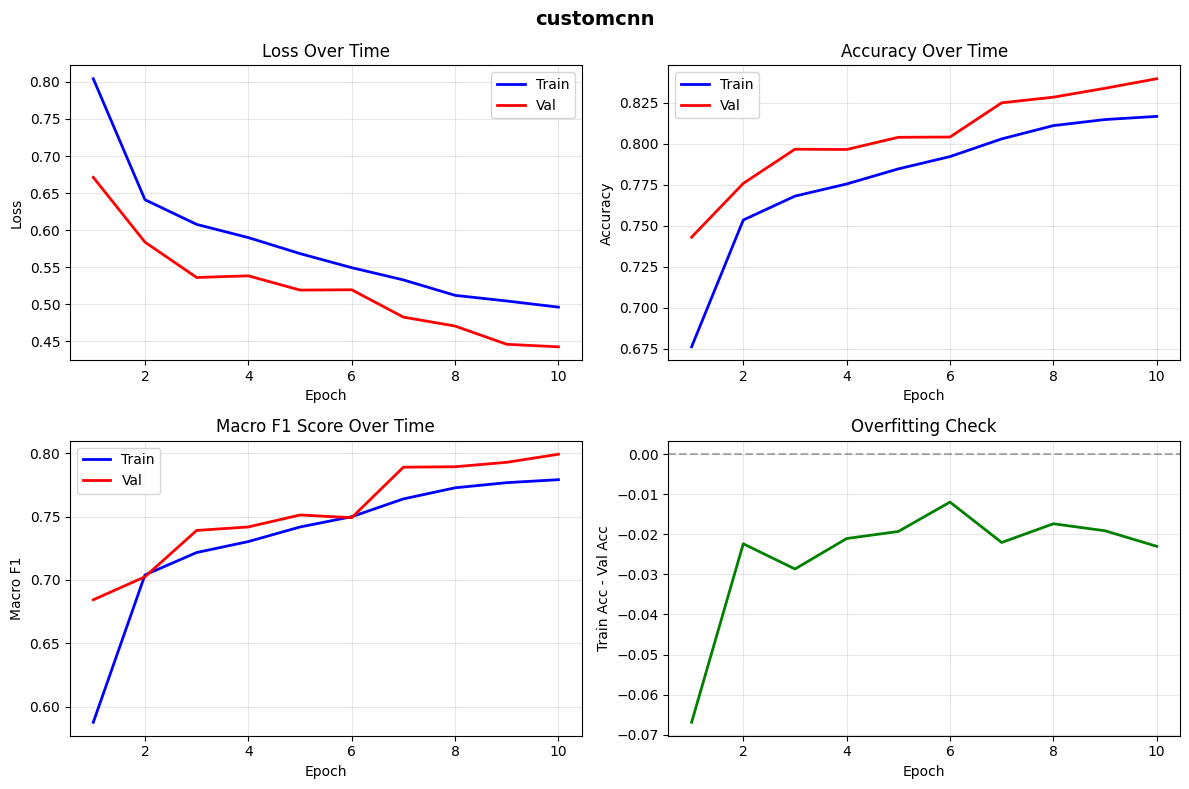

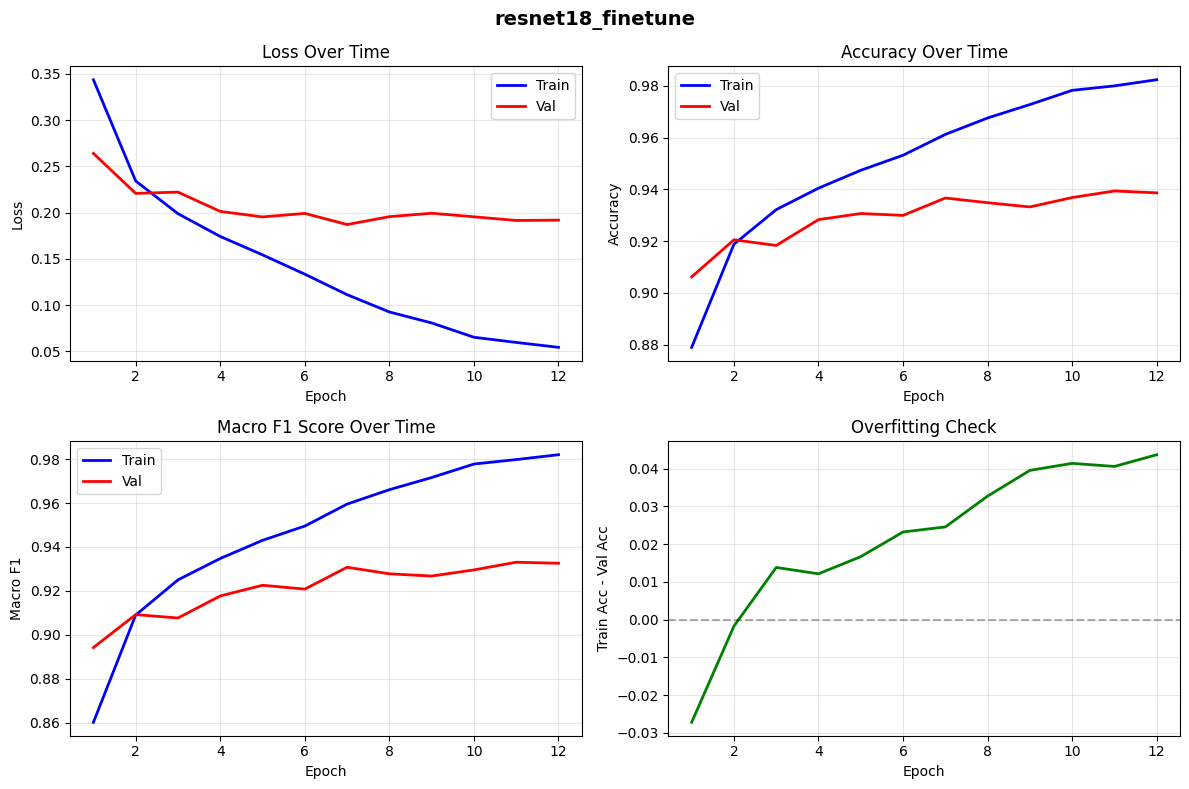

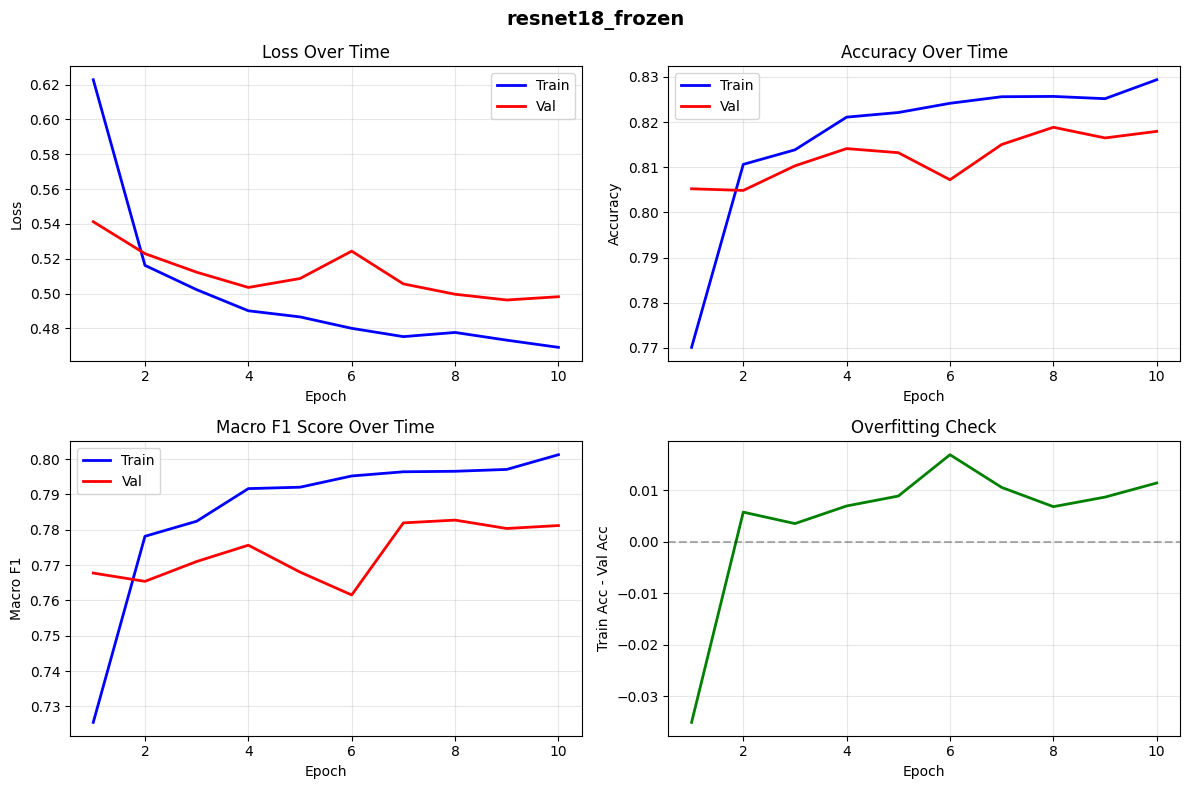

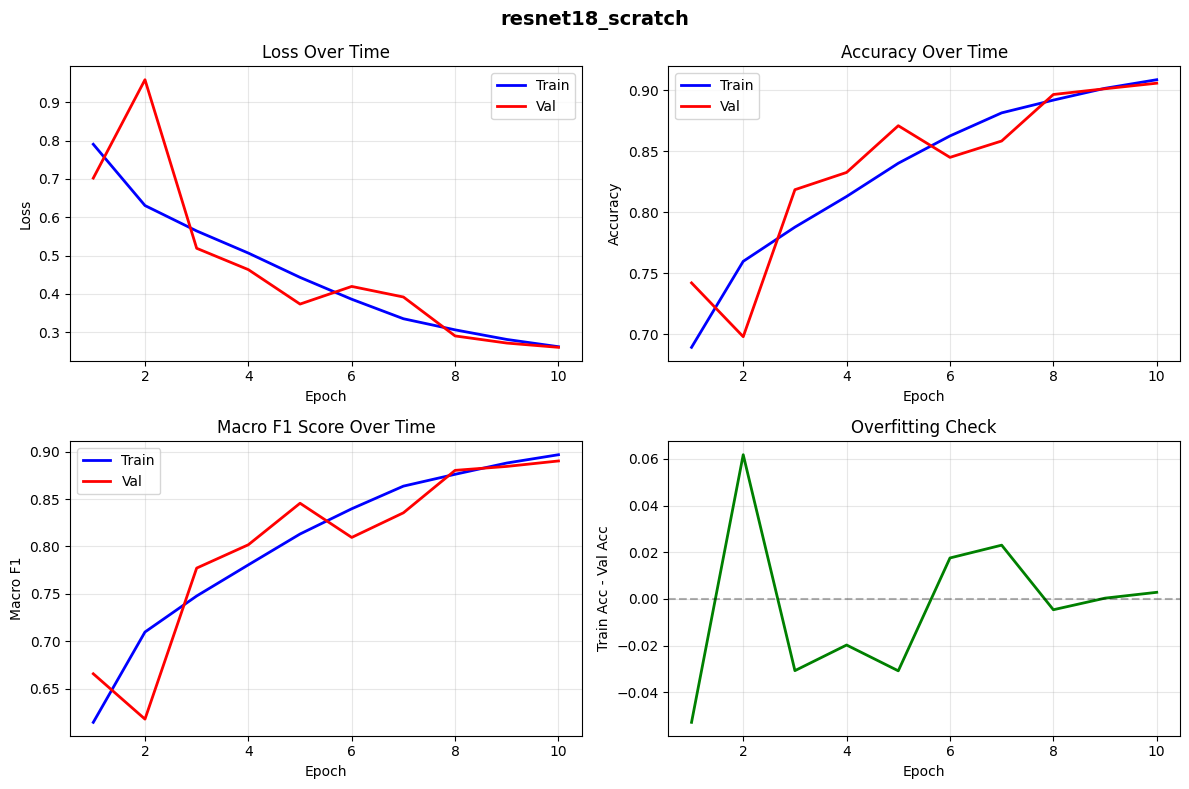

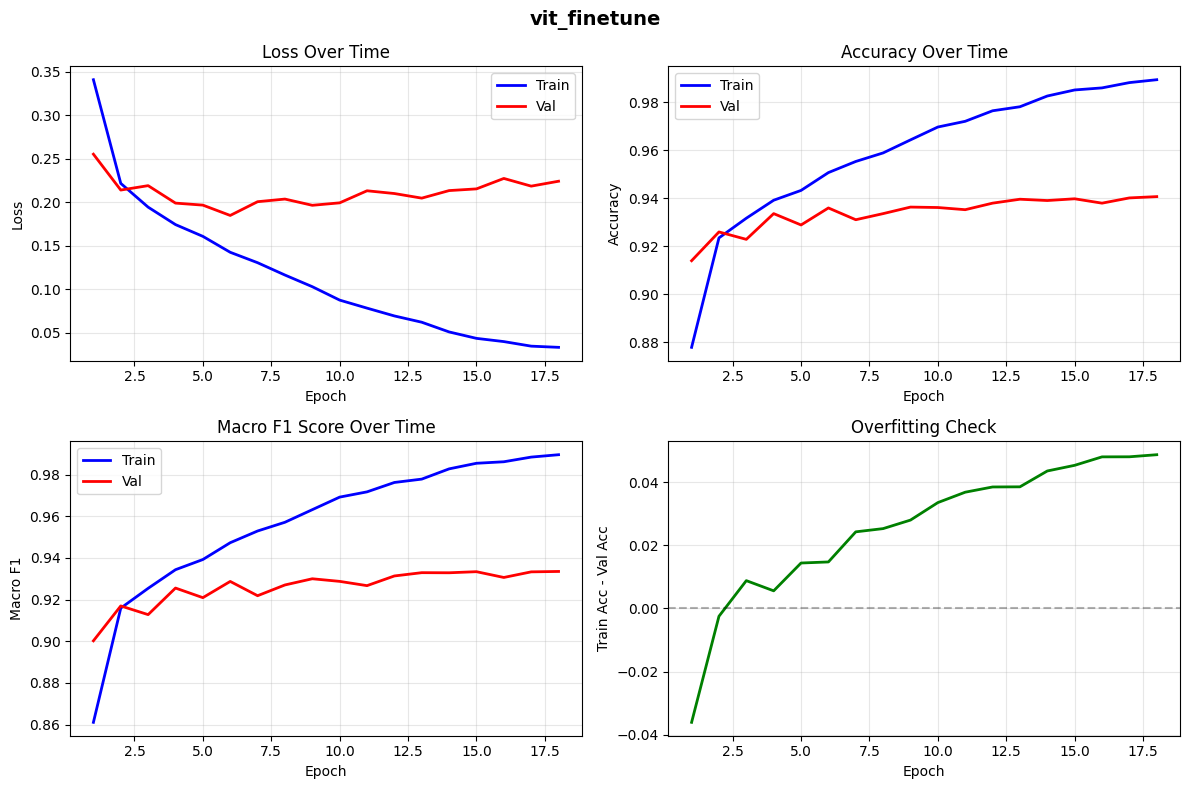

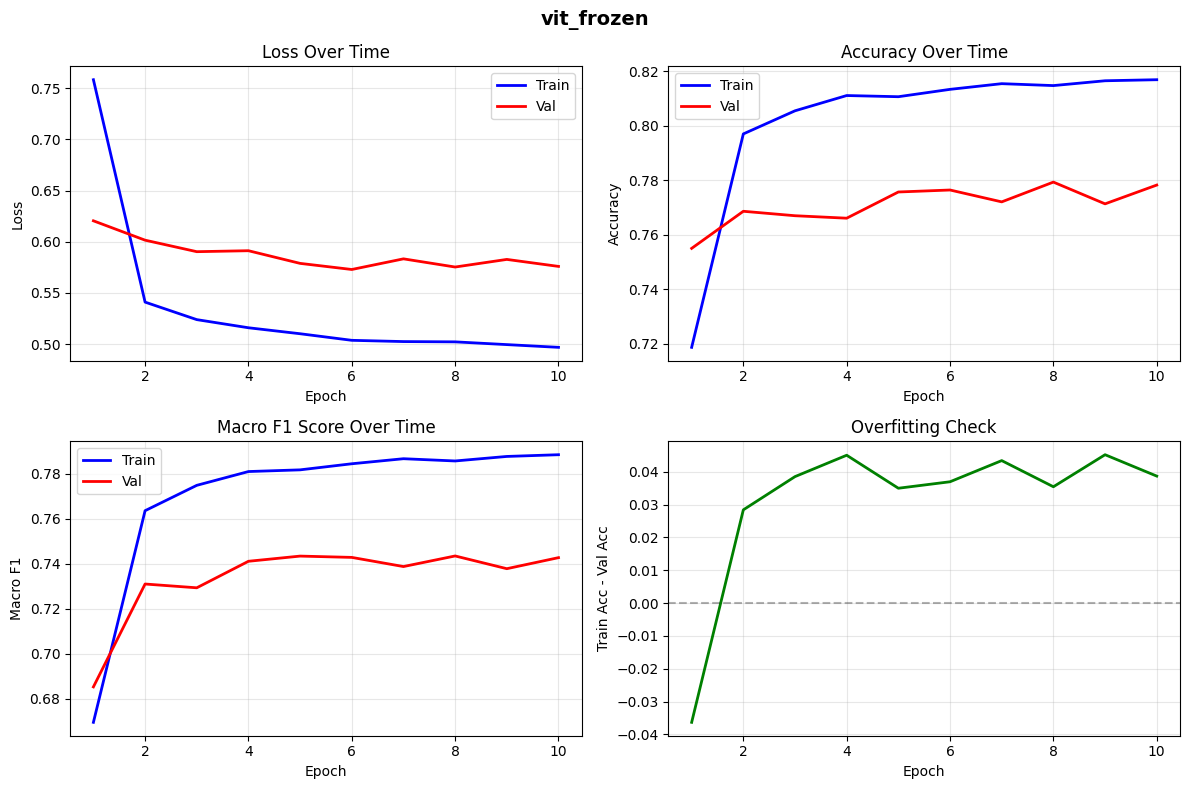

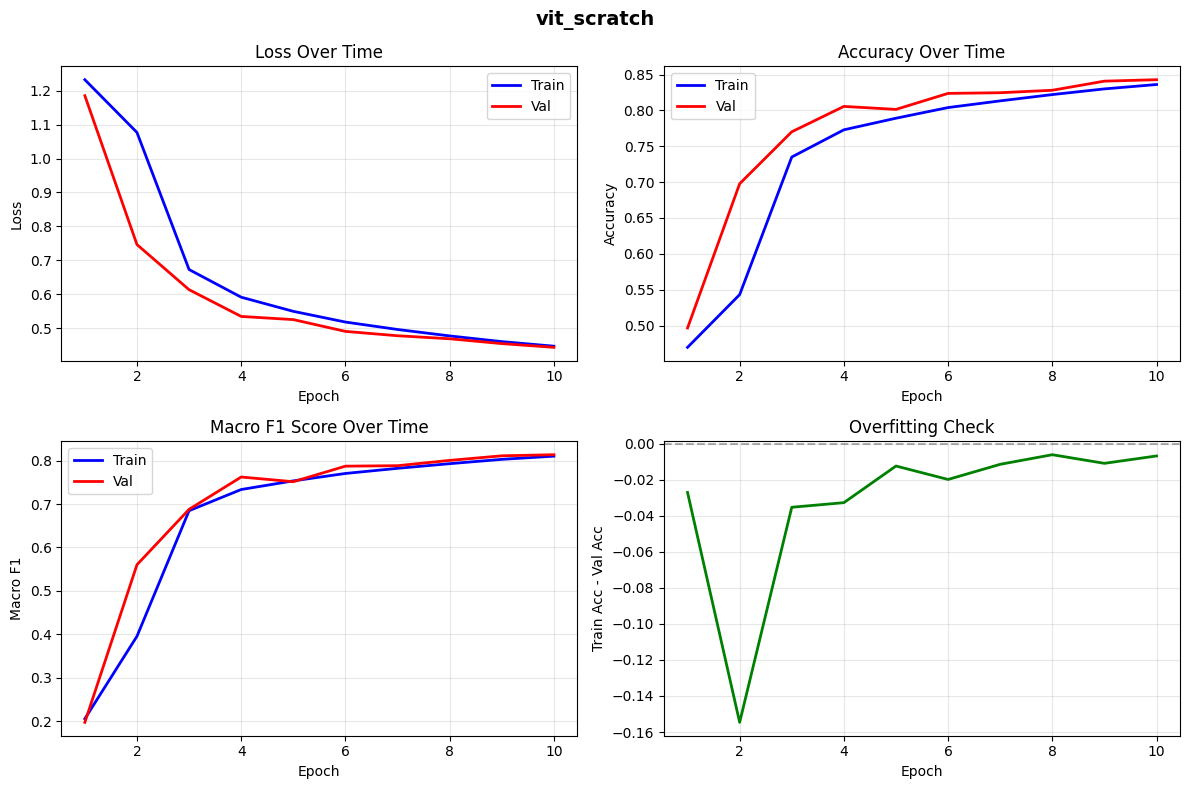

In [26]:
# find min_num of epochs
min_epochs = float('inf')
for model_name, history in histories.items():
    train_data = history['train']
    num_epochs = len(train_data)
    min_epochs = min(min_epochs, num_epochs)

print(f"Minimum epochs across all models: {min_epochs}")

for idx, (model_name, history) in enumerate(histories.items()):
    train_data = history['train']
    val_data = history['val']
    
    epochs_ind = [e['epoch'] for e in train_data]
    train_loss_ind = [e['loss'] for e in train_data]
    val_loss_ind = [e['loss'] for e in val_data]
    train_acc_ind = [e['accuracy'] for e in train_data]
    val_acc_ind = [e['accuracy'] for e in val_data]
    train_f1_ind = [e['macro_f1'] for e in train_data]
    val_f1_ind = [e['macro_f1'] for e in val_data]
    
    # calculate gap
    gap_ind = [t - v for t, v in zip(train_acc_ind, val_acc_ind)]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{model_name}', fontsize=14, fontweight='bold')
    
    # loss
    axes[0, 0].plot(epochs_ind, train_loss_ind, 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs_ind, val_loss_ind, 'r-', label='Val', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Over Time')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # accuracy
    axes[0, 1].plot(epochs_ind, train_acc_ind, 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs_ind, val_acc_ind, 'r-', label='Val', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy Over Time')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # f1
    axes[1, 0].plot(epochs_ind, train_f1_ind, 'b-', label='Train', linewidth=2)
    axes[1, 0].plot(epochs_ind, val_f1_ind, 'r-', label='Val', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Macro F1')
    axes[1, 0].set_title('Macro F1 Score Over Time')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # overfitting
    axes[1, 1].plot(epochs_ind, gap_ind, 'g-', linewidth=2)
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Train Acc - Val Acc')
    axes[1, 1].set_title('Overfitting Check')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    safe_model_name = model_name.replace('/', '-').replace('\\', '-')
    plt.savefig(f'outputs/{safe_model_name}/figures/{safe_model_name}_training_analysis.png', dpi=300, bbox_inches='tight')
    print(f"Saved: outputs/{safe_model_name}/figures/{safe_model_name}_training_analysis.png")
    # plt.close(fig)

Saved: outputs/comparisons/training_comparison.png
Saved: outputs/comparisons/best_validation_accuracy.png
Saved: outputs/comparisons/final_validation_metrics.png


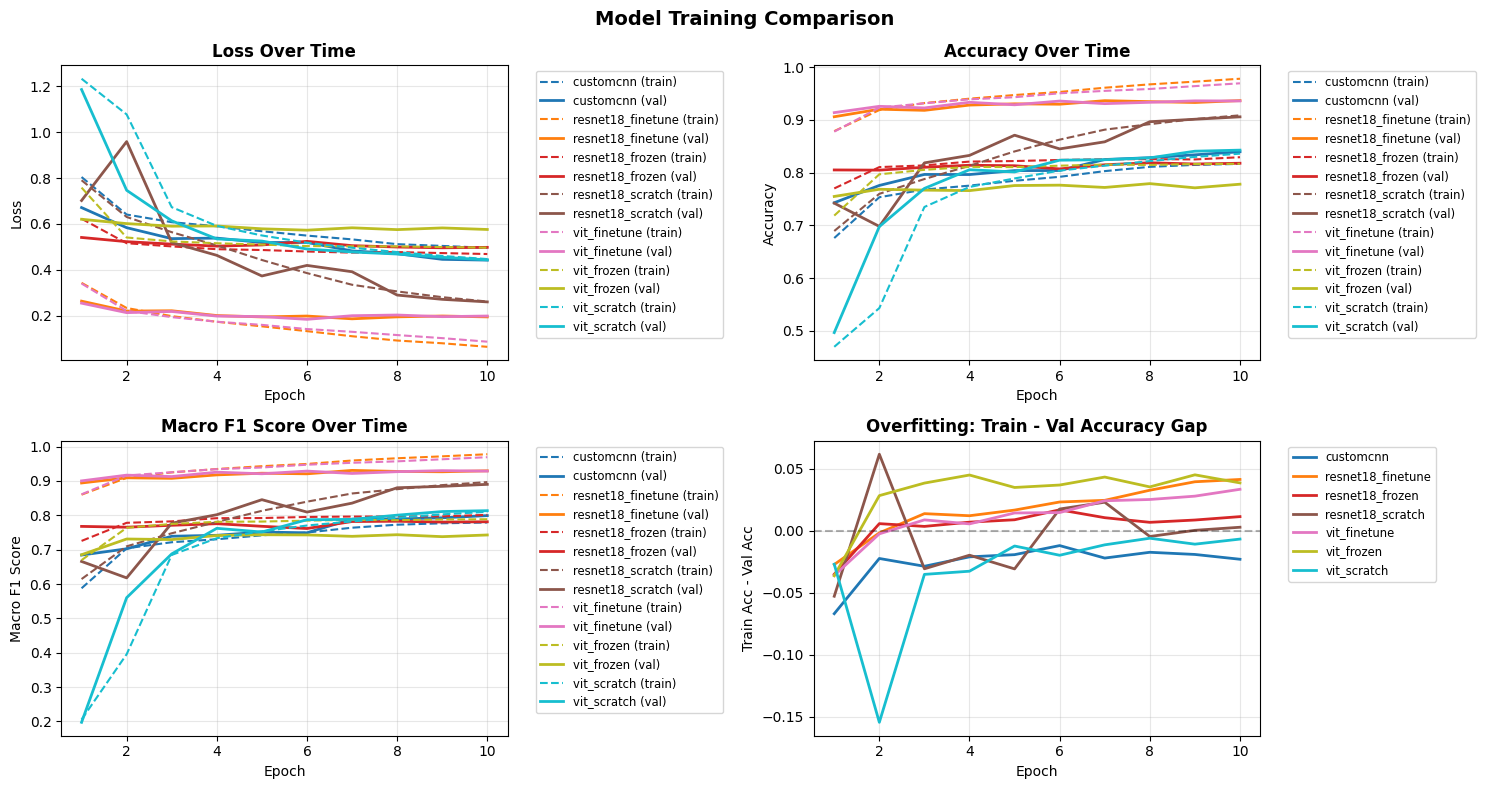

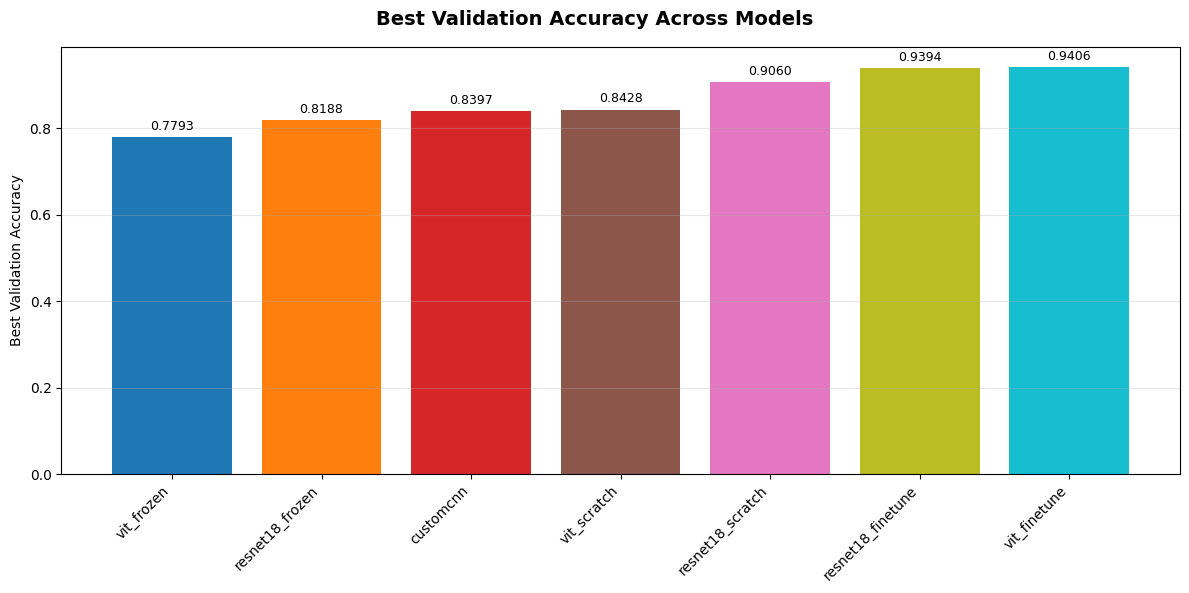

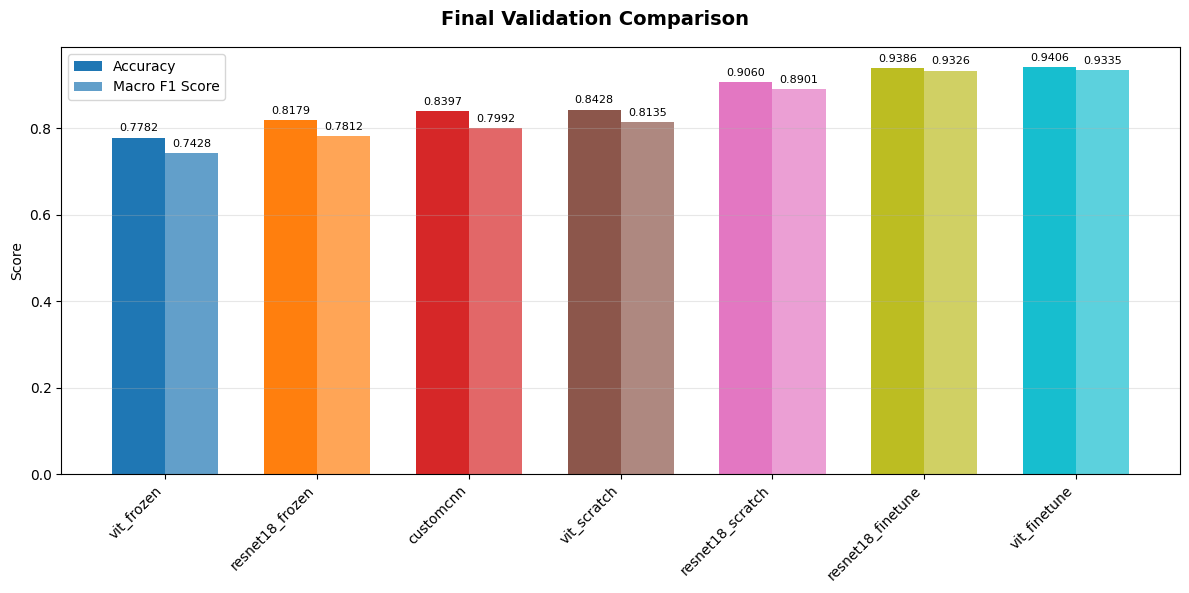

In [30]:
os.makedirs('outputs/comparisons', exist_ok=True)

# use epochs from first model up to min_epochs
first_history = list(histories.values())[0]
train_data_first = first_history['train'][:min_epochs]

epochs = [e['epoch'] for e in train_data_first]

# palette for different models
colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

# defines modeltypes
model_types = list(histories.keys())

# 2x2 plot loss, accuracy, f1, overfitting 
fig1, axes1 = plt.subplots(2, 2, figsize=(15, 8))
fig1.suptitle("Model Training Comparison", fontsize=14, fontweight='bold')

# loss
axes1[0, 0].set_title('Loss Over Time', fontweight='bold')
for idx, (model_name, history) in enumerate(histories.items()):
    train_data = history['train'][:min_epochs]
    val_data = history['val'][:min_epochs]
    train_loss = [e['loss'] for e in train_data]
    val_loss = [e['loss'] for e in val_data]
    axes1[0, 0].plot(epochs, train_loss, '--', color=colors[idx], label=f'{model_name} (train)', linewidth=1.5)
    axes1[0, 0].plot(epochs, val_loss, '-', color=colors[idx], label=f'{model_name} (val)', linewidth=2)
axes1[0, 0].set_xlabel('Epoch')
axes1[0, 0].set_ylabel('Loss')
axes1[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes1[0, 0].grid(True, alpha=0.3)

# acurracy
axes1[0, 1].set_title('Accuracy Over Time', fontweight='bold')
for idx, (model_name, history) in enumerate(histories.items()):
    train_data = history['train'][:min_epochs]
    val_data = history['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    axes1[0, 1].plot(epochs, train_acc, '--', color=colors[idx], label=f'{model_name} (train)', linewidth=1.5)
    axes1[0, 1].plot(epochs, val_acc, '-', color=colors[idx], label=f'{model_name} (val)', linewidth=2)
axes1[0, 1].set_xlabel('Epoch')
axes1[0, 1].set_ylabel('Accuracy')
axes1[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes1[0, 1].grid(True, alpha=0.3)

# f1
axes1[1, 0].set_title('Macro F1 Score Over Time', fontweight='bold')
for idx, (model_name, history) in enumerate(histories.items()):
    train_data = history['train'][:min_epochs]
    val_data = history['val'][:min_epochs]
    train_f1 = [e['macro_f1'] for e in train_data]
    val_f1 = [e['macro_f1'] for e in val_data]
    axes1[1, 0].plot(epochs, train_f1, '--', color=colors[idx], label=f'{model_name} (train)', linewidth=1.5)
    axes1[1, 0].plot(epochs, val_f1, '-', color=colors[idx], label=f'{model_name} (val)', linewidth=2)
axes1[1, 0].set_xlabel('Epoch')
axes1[1, 0].set_ylabel('Macro F1 Score')
axes1[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes1[1, 0].grid(True, alpha=0.3)

# overfitting
axes1[1, 1].set_title('Overfitting: Train - Val Accuracy Gap', fontweight='bold')
for idx, (model_name, history) in enumerate(histories.items()):
    train_data = history['train'][:min_epochs]
    val_data = history['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    axes1[1, 1].plot(epochs, gap, '-', color=colors[idx], label=model_name, linewidth=2)
axes1[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes1[1, 1].set_xlabel('Epoch')
axes1[1, 1].set_ylabel('Train Acc - Val Acc')
axes1[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes1[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/comparisons/training_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/training_comparison.png")
# plt.close()

# best accuracy
best_val_accs = []
for model_name in model_types:
    history = histories[model_name]
    val_data = history['val']
    val_acc = [e['accuracy'] for e in val_data]
    best_val_accs.append(max(val_acc))

best_val_accs, model_types_sorted = zip(
    *sorted(zip(best_val_accs, model_types))
)
best_val_accs = list(best_val_accs)
model_types = list(model_types_sorted)


fig2, ax2 = plt.subplots(1, 1, figsize=(12, 6))
fig2.suptitle('Best Validation Accuracy Across Models', fontsize=14, fontweight='bold')

x_pos = np.arange(len(model_types))
bars = ax2.bar(x_pos, best_val_accs, color=colors[:len(histories)])
ax2.set_xticks(x_pos)
ax2.set_xticklabels(model_types, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Best Validation Accuracy')
ax2.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, best_val_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/comparisons/best_validation_accuracy.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/best_validation_accuracy.png")
# plt.close()

# final validation
final_accs = []
final_f1s = []
for model_name in model_types:
    history = histories[model_name]
    val_data = history['val']
    final_accs.append(val_data[-1]['accuracy'])
    final_f1s.append(val_data[-1]['macro_f1'])

fig3, ax3 = plt.subplots(1, 1, figsize=(12, 6))
fig3.suptitle('Final Validation Comparison', fontsize=14, fontweight='bold')
width = 0.35

x_pos = np.arange(len(model_types))
bars_acc = ax3.bar(x_pos - width/2, final_accs, width, label='Accuracy', color=colors[:len(histories)])
bars_f1 = ax3.bar(x_pos + width/2, final_f1s, width, label='Macro F1 Score', color=colors[:len(histories)], alpha=0.7)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(model_types, rotation=45, ha='right', fontsize=10)
ax3.set_ylabel('Score')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars_acc, final_accs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=8)

for bar, f1 in zip(bars_f1, final_f1s):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{f1:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/comparisons/final_validation_metrics.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/final_validation_metrics.png")
# plt.close()

Saved: outputs/comparisons/vit_variants_comparison.png
Saved: outputs/comparisons/resnet18_variants_comparison.png
Saved: outputs/comparisons/vit_vs_customcnn_comparison.png
Saved: outputs/comparisons/resnet18_vs_customcnn_comparison.png


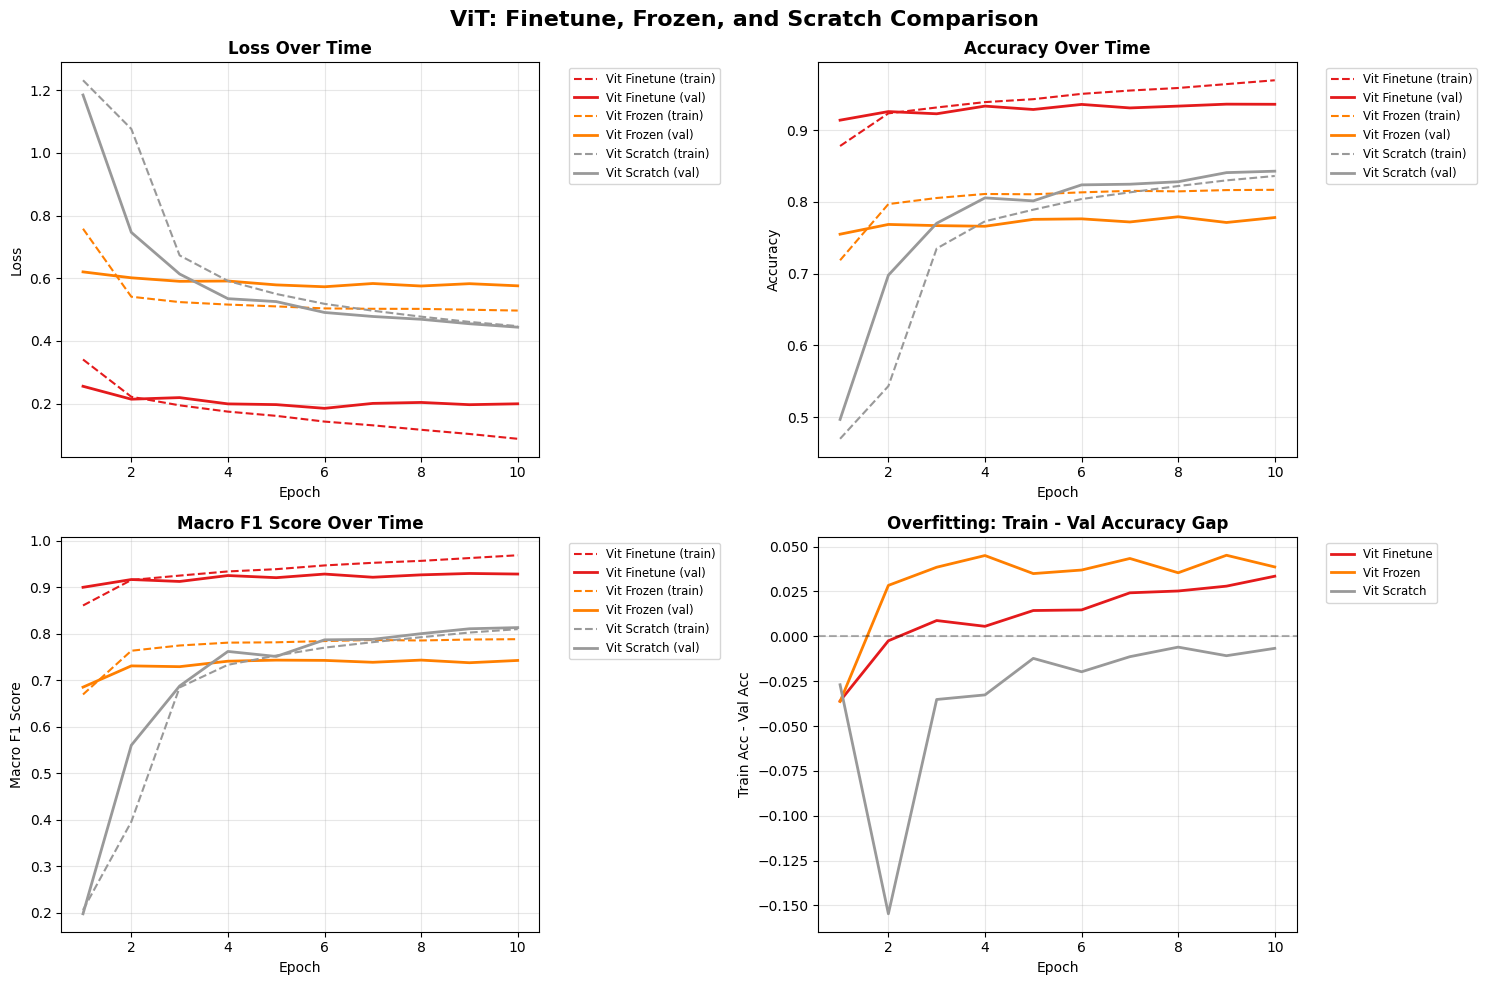

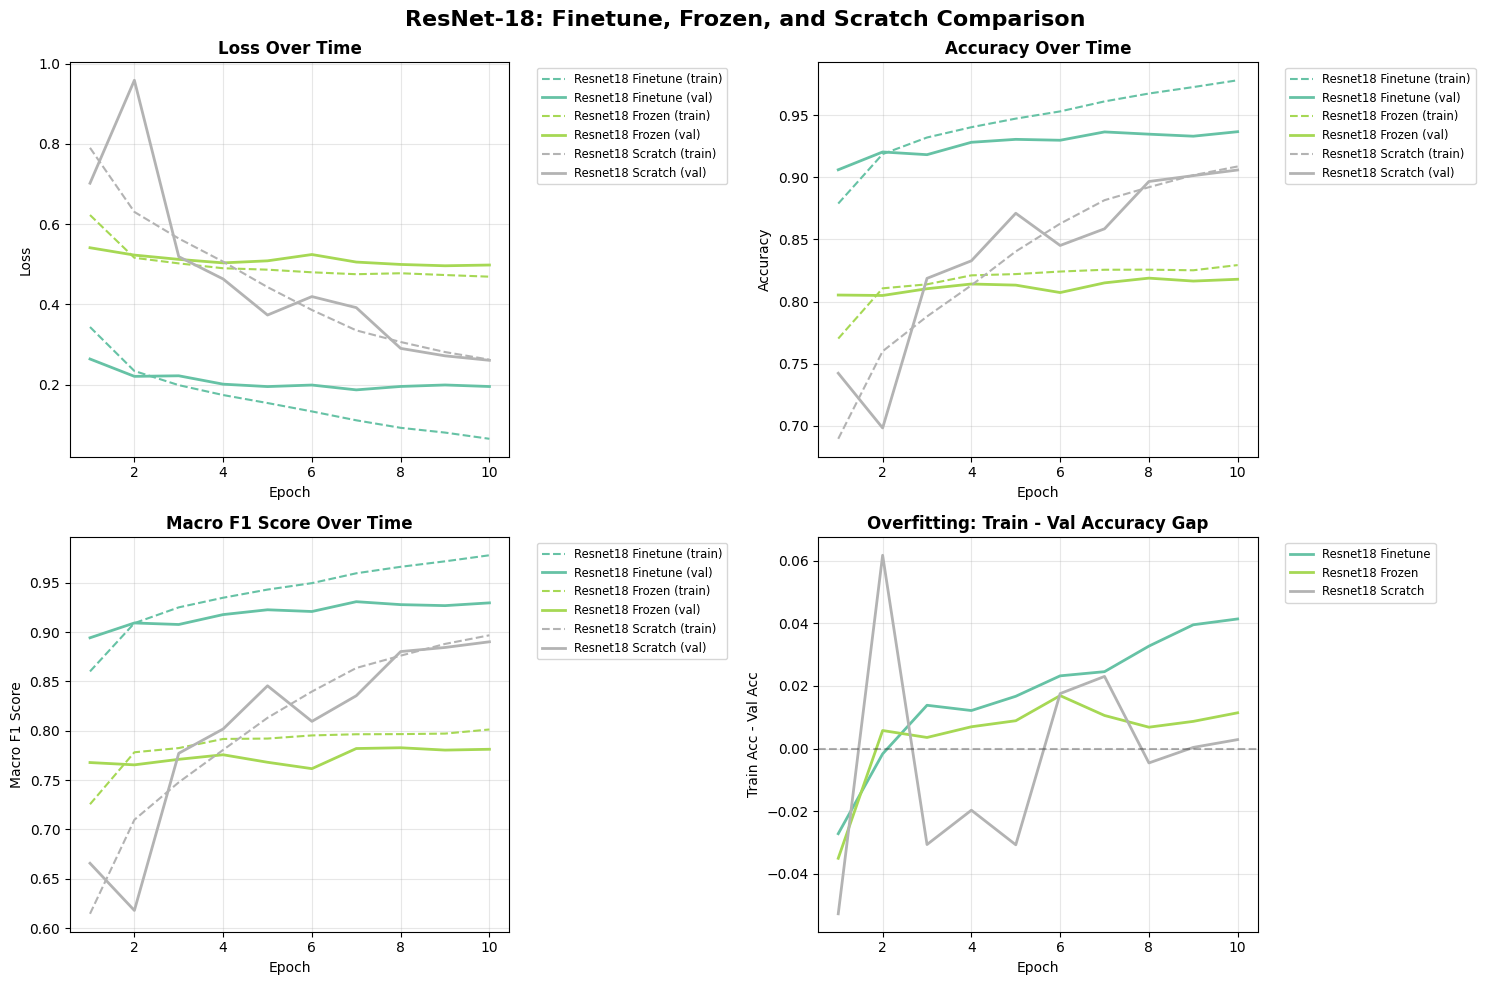

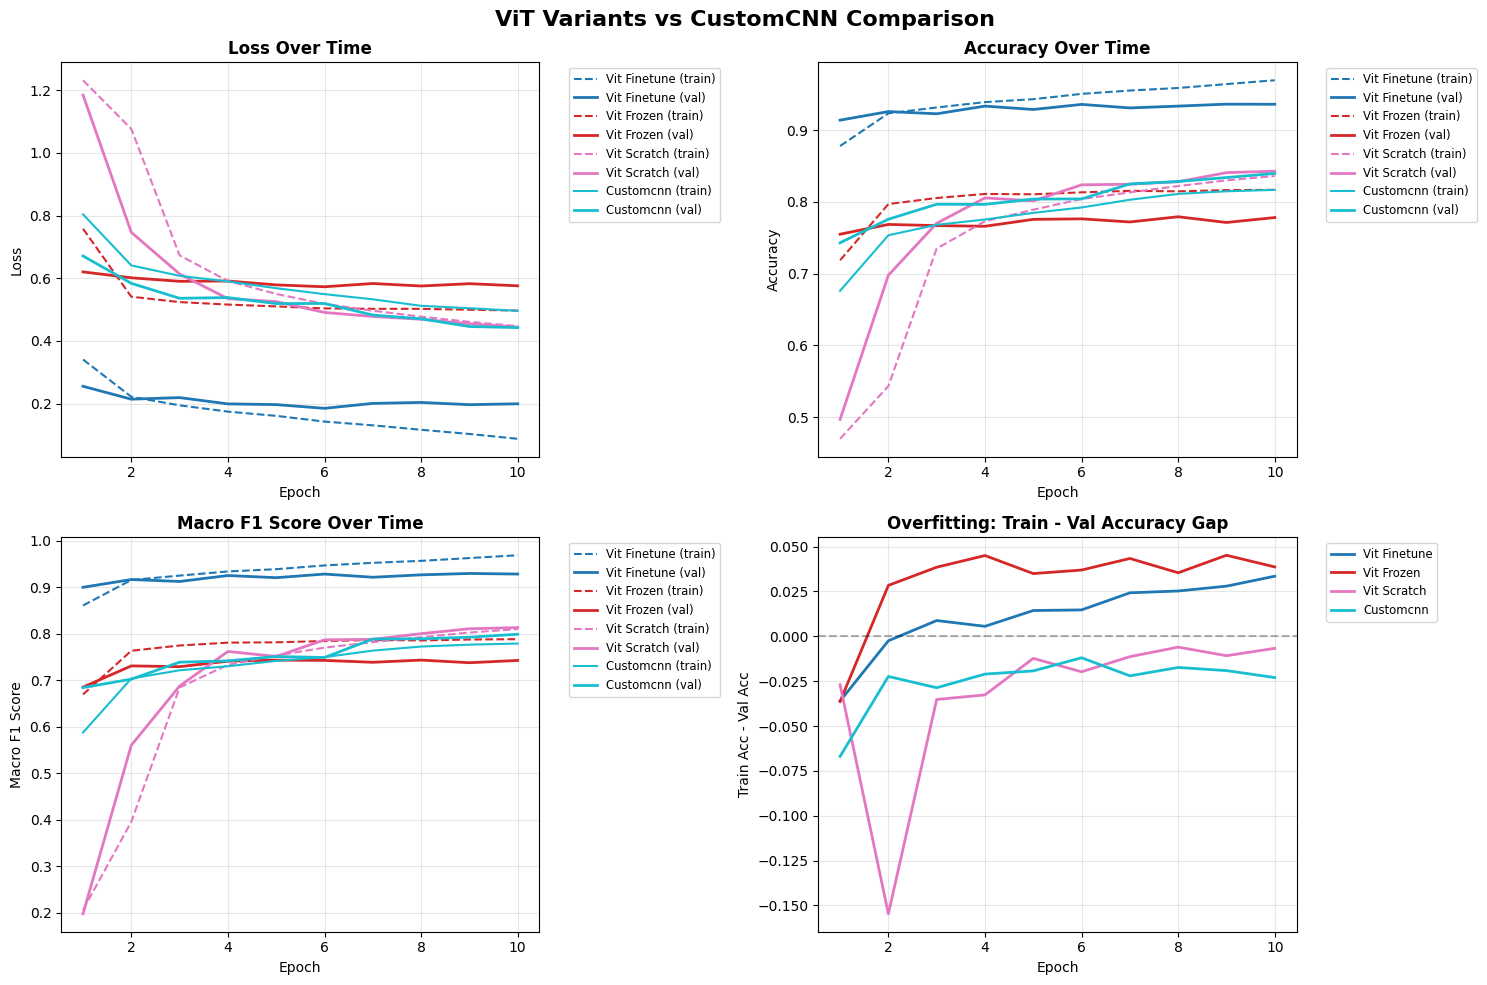

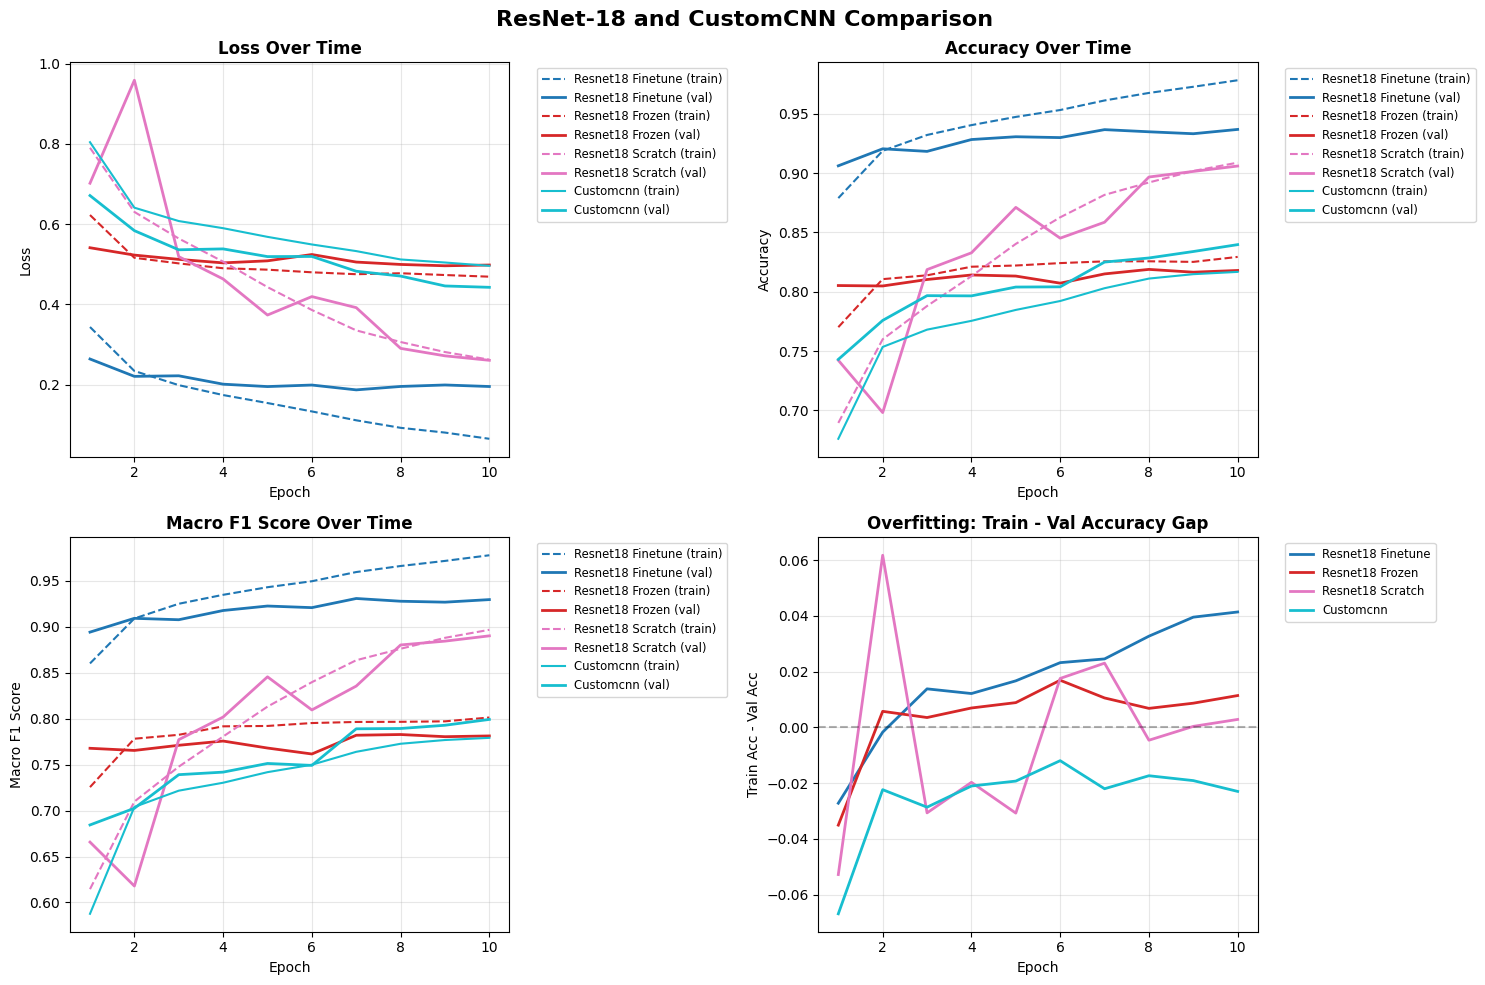

In [27]:
# model groups for comparison
vit_models = ['vit_finetune', 'vit_frozen', 'vit_scratch']
resnet_models = ['resnet18_finetune', 'resnet18_frozen', 'resnet18_scratch']
vit_cnn_models = ['vit_finetune', 'vit_frozen', 'vit_scratch', 'customcnn']
resnet_cnn_models = ['resnet18_finetune', 'resnet18_frozen', 'resnet18_scratch', 'customcnn']

# filtering for groups
existing_vit = [m for m in vit_models if m in histories]
existing_resnet = [m for m in resnet_models if m in histories]
existing_vit_cnn = [m for m in vit_cnn_models if m in histories]
existing_resnet_cnn = [m for m in resnet_cnn_models if m in histories]

# colors
colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))
vit_colors = plt.cm.Set1(np.linspace(0, 1, 3))
resnet_colors = plt.cm.Set2(np.linspace(0, 1, 3))
customcnn_color = plt.cm.tab10(7)

# gets colors for list
def get_model_colors(models, base_palette):
    if len(models) <= 3:
        return {m: base_palette[i] for i, m in enumerate(models)}

    all_colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    return {m: all_colors[i] for i, m in enumerate(models)}

# vit variants
fig_vit, axes_vit = plt.subplots(2, 2, figsize=(15, 10))
fig_vit.suptitle("ViT: Finetune, Frozen, and Scratch Comparison", fontsize=16, fontweight='bold')

colors_vit = get_model_colors(existing_vit, vit_colors)

# loss
axes_vit[0, 0].set_title('Loss Over Time', fontweight='bold')
for model_name in existing_vit:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_loss = [e['loss'] for e in train_data]
    val_loss = [e['loss'] for e in val_data]
    color = colors_vit[model_name]
    axes_vit[0, 0].plot(epochs, train_loss, '--', color=color, label=f'{model_name.replace("_", " ").title()} (train)', linewidth=1.5)
    axes_vit[0, 0].plot(epochs, val_loss, '-', color=color, label=f'{model_name.replace("_", " ").title()} (val)', linewidth=2)
axes_vit[0, 0].set_xlabel('Epoch')
axes_vit[0, 0].set_ylabel('Loss')
axes_vit[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit[0, 0].grid(True, alpha=0.3)

# accuracy
axes_vit[0, 1].set_title('Accuracy Over Time', fontweight='bold')
for model_name in existing_vit:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    color = colors_vit[model_name]
    axes_vit[0, 1].plot(epochs, train_acc, '--', color=color, label=f'{model_name.replace("_", " ").title()} (train)', linewidth=1.5)
    axes_vit[0, 1].plot(epochs, val_acc, '-', color=color, label=f'{model_name.replace("_", " ").title()} (val)', linewidth=2)
axes_vit[0, 1].set_xlabel('Epoch')
axes_vit[0, 1].set_ylabel('Accuracy')
axes_vit[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit[0, 1].grid(True, alpha=0.3)

# f1
axes_vit[1, 0].set_title('Macro F1 Score Over Time', fontweight='bold')
for model_name in existing_vit:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_f1 = [e['macro_f1'] for e in train_data]
    val_f1 = [e['macro_f1'] for e in val_data]
    color = colors_vit[model_name]
    axes_vit[1, 0].plot(epochs, train_f1, '--', color=color, label=f'{model_name.replace("_", " ").title()} (train)', linewidth=1.5)
    axes_vit[1, 0].plot(epochs, val_f1, '-', color=color, label=f'{model_name.replace("_", " ").title()} (val)', linewidth=2)
axes_vit[1, 0].set_xlabel('Epoch')
axes_vit[1, 0].set_ylabel('Macro F1 Score')
axes_vit[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit[1, 0].grid(True, alpha=0.3)

# overfitting
axes_vit[1, 1].set_title('Overfitting: Train - Val Accuracy Gap', fontweight='bold')
for model_name in existing_vit:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    color = colors_vit[model_name]
    axes_vit[1, 1].plot(epochs, gap, '-', color=color, label=model_name.replace("_", " ").title(), linewidth=2)
axes_vit[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes_vit[1, 1].set_xlabel('Epoch')
axes_vit[1, 1].set_ylabel('Train Acc - Val Acc')
axes_vit[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/comparisons/vit_variants_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/vit_variants_comparison.png")
# plt.close(fig_vit)

# resent18 variants
fig_resnet, axes_resnet = plt.subplots(2, 2, figsize=(15, 10))
fig_resnet.suptitle("ResNet-18: Finetune, Frozen, and Scratch Comparison", fontsize=16, fontweight='bold')

colors_resnet = get_model_colors(existing_resnet, resnet_colors)

# loss
axes_resnet[0, 0].set_title('Loss Over Time', fontweight='bold')
for model_name in existing_resnet:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_loss = [e['loss'] for e in train_data]
    val_loss = [e['loss'] for e in val_data]
    color = colors_resnet[model_name]
    axes_resnet[0, 0].plot(epochs, train_loss, '--', color=color, label=f'{model_name.replace("_", " ").title()} (train)', linewidth=1.5)
    axes_resnet[0, 0].plot(epochs, val_loss, '-', color=color, label=f'{model_name.replace("_", " ").title()} (val)', linewidth=2)
axes_resnet[0, 0].set_xlabel('Epoch')
axes_resnet[0, 0].set_ylabel('Loss')
axes_resnet[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet[0, 0].grid(True, alpha=0.3)

# accuracy
axes_resnet[0, 1].set_title('Accuracy Over Time', fontweight='bold')
for model_name in existing_resnet:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    color = colors_resnet[model_name]
    axes_resnet[0, 1].plot(epochs, train_acc, '--', color=color, label=f'{model_name.replace("_", " ").title()} (train)', linewidth=1.5)
    axes_resnet[0, 1].plot(epochs, val_acc, '-', color=color, label=f'{model_name.replace("_", " ").title()} (val)', linewidth=2)
axes_resnet[0, 1].set_xlabel('Epoch')
axes_resnet[0, 1].set_ylabel('Accuracy')
axes_resnet[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet[0, 1].grid(True, alpha=0.3)

# f1
axes_resnet[1, 0].set_title('Macro F1 Score Over Time', fontweight='bold')
for model_name in existing_resnet:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_f1 = [e['macro_f1'] for e in train_data]
    val_f1 = [e['macro_f1'] for e in val_data]
    color = colors_resnet[model_name]
    axes_resnet[1, 0].plot(epochs, train_f1, '--', color=color, label=f'{model_name.replace("_", " ").title()} (train)', linewidth=1.5)
    axes_resnet[1, 0].plot(epochs, val_f1, '-', color=color, label=f'{model_name.replace("_", " ").title()} (val)', linewidth=2)
axes_resnet[1, 0].set_xlabel('Epoch')
axes_resnet[1, 0].set_ylabel('Macro F1 Score')
axes_resnet[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet[1, 0].grid(True, alpha=0.3)

# overfitting
axes_resnet[1, 1].set_title('Overfitting: Train - Val Accuracy Gap', fontweight='bold')
for model_name in existing_resnet:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    color = colors_resnet[model_name]
    axes_resnet[1, 1].plot(epochs, gap, '-', color=color, label=model_name.replace("_", " ").title(), linewidth=2)
axes_resnet[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes_resnet[1, 1].set_xlabel('Epoch')
axes_resnet[1, 1].set_ylabel('Train Acc - Val Acc')
axes_resnet[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/comparisons/resnet18_variants_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/resnet18_variants_comparison.png")
# plt.close(fig_resnet)

# vit and customcnn variants
fig_vit_cnn, axes_vit_cnn = plt.subplots(2, 2, figsize=(15, 10))
fig_vit_cnn.suptitle("ViT Variants vs CustomCNN Comparison", fontsize=16, fontweight='bold')

colors_vit_cnn = get_model_colors(existing_vit_cnn, plt.cm.tab10(np.linspace(0, 1, len(existing_vit_cnn))))

# loss
axes_vit_cnn[0, 0].set_title('Loss Over Time', fontweight='bold')
for model_name in existing_vit_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_loss = [e['loss'] for e in train_data]
    val_loss = [e['loss'] for e in val_data]
    color = colors_vit_cnn[model_name]
    is_vit = 'vit' in model_name
    marker_style = '--' if is_vit else '-'
    display_name = model_name.replace("_", " ").title()
    axes_vit_cnn[0, 0].plot(epochs, train_loss, marker_style, color=color, label=f'{display_name} (train)', linewidth=1.5)
    axes_vit_cnn[0, 0].plot(epochs, val_loss, '-', color=color, label=f'{display_name} (val)', linewidth=2)
axes_vit_cnn[0, 0].set_xlabel('Epoch')
axes_vit_cnn[0, 0].set_ylabel('Loss')
axes_vit_cnn[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit_cnn[0, 0].grid(True, alpha=0.3)

# accuracy
axes_vit_cnn[0, 1].set_title('Accuracy Over Time', fontweight='bold')
for model_name in existing_vit_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    color = colors_vit_cnn[model_name]
    is_vit = 'vit' in model_name
    marker_style = '--' if is_vit else '-'
    display_name = model_name.replace("_", " ").title()
    axes_vit_cnn[0, 1].plot(epochs, train_acc, marker_style, color=color, label=f'{display_name} (train)', linewidth=1.5)
    axes_vit_cnn[0, 1].plot(epochs, val_acc, '-', color=color, label=f'{display_name} (val)', linewidth=2)
axes_vit_cnn[0, 1].set_xlabel('Epoch')
axes_vit_cnn[0, 1].set_ylabel('Accuracy')
axes_vit_cnn[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit_cnn[0, 1].grid(True, alpha=0.3)

# f1
axes_vit_cnn[1, 0].set_title('Macro F1 Score Over Time', fontweight='bold')
for model_name in existing_vit_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_f1 = [e['macro_f1'] for e in train_data]
    val_f1 = [e['macro_f1'] for e in val_data]
    color = colors_vit_cnn[model_name]
    is_vit = 'vit' in model_name
    marker_style = '--' if is_vit else '-'
    display_name = model_name.replace("_", " ").title()
    axes_vit_cnn[1, 0].plot(epochs, train_f1, marker_style, color=color, label=f'{display_name} (train)', linewidth=1.5)
    axes_vit_cnn[1, 0].plot(epochs, val_f1, '-', color=color, label=f'{display_name} (val)', linewidth=2)
axes_vit_cnn[1, 0].set_xlabel('Epoch')
axes_vit_cnn[1, 0].set_ylabel('Macro F1 Score')
axes_vit_cnn[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit_cnn[1, 0].grid(True, alpha=0.3)

# overfitting
axes_vit_cnn[1, 1].set_title('Overfitting: Train - Val Accuracy Gap', fontweight='bold')
for model_name in existing_vit_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    color = colors_vit_cnn[model_name]
    display_name = model_name.replace("_", " ").title()
    axes_vit_cnn[1, 1].plot(epochs, gap, '-', color=color, label=display_name, linewidth=2)
axes_vit_cnn[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes_vit_cnn[1, 1].set_xlabel('Epoch')
axes_vit_cnn[1, 1].set_ylabel('Train Acc - Val Acc')
axes_vit_cnn[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_vit_cnn[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/comparisons/vit_vs_customcnn_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/vit_vs_customcnn_comparison.png")
# plt.close(fig_vit_cnn)

# resnet18 and customcnn comparison
fig_resnet_cnn, axes_resnet_cnn = plt.subplots(2, 2, figsize=(15, 10))
fig_resnet_cnn.suptitle("ResNet-18 and CustomCNN Comparison", fontsize=16, fontweight='bold')

colors_resnet_cnn = get_model_colors(existing_resnet_cnn, plt.cm.tab10(np.linspace(0, 1, len(existing_resnet_cnn))))

# loss
axes_resnet_cnn[0, 0].set_title('Loss Over Time', fontweight='bold')
for model_name in existing_resnet_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_loss = [e['loss'] for e in train_data]
    val_loss = [e['loss'] for e in val_data]
    color = colors_resnet_cnn[model_name]
    is_resnet = 'resnet18' in model_name
    marker_style = '--' if is_resnet else '-'
    display_name = model_name.replace("_", " ").title()
    axes_resnet_cnn[0, 0].plot(epochs, train_loss, marker_style, color=color, label=f'{display_name} (train)', linewidth=1.5)
    axes_resnet_cnn[0, 0].plot(epochs, val_loss, '-', color=color, label=f'{display_name} (val)', linewidth=2)
axes_resnet_cnn[0, 0].set_xlabel('Epoch')
axes_resnet_cnn[0, 0].set_ylabel('Loss')
axes_resnet_cnn[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet_cnn[0, 0].grid(True, alpha=0.3)

# accuracy
axes_resnet_cnn[0, 1].set_title('Accuracy Over Time', fontweight='bold')
for model_name in existing_resnet_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    color = colors_resnet_cnn[model_name]
    is_resnet = 'resnet18' in model_name
    marker_style = '--' if is_resnet else '-'
    display_name = model_name.replace("_", " ").title()
    axes_resnet_cnn[0, 1].plot(epochs, train_acc, marker_style, color=color, label=f'{display_name} (train)', linewidth=1.5)
    axes_resnet_cnn[0, 1].plot(epochs, val_acc, '-', color=color, label=f'{display_name} (val)', linewidth=2)
axes_resnet_cnn[0, 1].set_xlabel('Epoch')
axes_resnet_cnn[0, 1].set_ylabel('Accuracy')
axes_resnet_cnn[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet_cnn[0, 1].grid(True, alpha=0.3)

# f1
axes_resnet_cnn[1, 0].set_title('Macro F1 Score Over Time', fontweight='bold')
for model_name in existing_resnet_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_f1 = [e['macro_f1'] for e in train_data]
    val_f1 = [e['macro_f1'] for e in val_data]
    color = colors_resnet_cnn[model_name]
    is_resnet = 'resnet18' in model_name
    marker_style = '--' if is_resnet else '-'
    display_name = model_name.replace("_", " ").title()
    axes_resnet_cnn[1, 0].plot(epochs, train_f1, marker_style, color=color, label=f'{display_name} (train)', linewidth=1.5)
    axes_resnet_cnn[1, 0].plot(epochs, val_f1, '-', color=color, label=f'{display_name} (val)', linewidth=2)
axes_resnet_cnn[1, 0].set_xlabel('Epoch')
axes_resnet_cnn[1, 0].set_ylabel('Macro F1 Score')
axes_resnet_cnn[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet_cnn[1, 0].grid(True, alpha=0.3)

# overfitting
axes_resnet_cnn[1, 1].set_title('Overfitting: Train - Val Accuracy Gap', fontweight='bold')
for model_name in existing_resnet_cnn:
    train_data = histories[model_name]['train'][:min_epochs]
    val_data = histories[model_name]['val'][:min_epochs]
    train_acc = [e['accuracy'] for e in train_data]
    val_acc = [e['accuracy'] for e in val_data]
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    color = colors_resnet_cnn[model_name]
    display_name = model_name.replace("_", " ").title()
    axes_resnet_cnn[1, 1].plot(epochs, gap, '-', color=color, label=display_name, linewidth=2)
axes_resnet_cnn[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes_resnet_cnn[1, 1].set_xlabel('Epoch')
axes_resnet_cnn[1, 1].set_ylabel('Train Acc - Val Acc')
axes_resnet_cnn[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes_resnet_cnn[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/comparisons/resnet18_vs_customcnn_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: outputs/comparisons/resnet18_vs_customcnn_comparison.png")
# plt.close(fig_resnet_cnn)